# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [59]:
train = pd.read_csv('nba.csv')
train.head()

,rank,player,position,teams,total_points,total_games,points_per_game,field_goals,three_points_goals,free_shots,born,active_player,hall_of_fame,country
0,1,LeBron James,SF,"Cleveland Cavaliers (2003–2010, 2014–2018)\nMi...",39201,1443,27.2,14356,2311,8178,1984,1,NaN,USA
1,2,Kareem Abdul-Jabbar,C,Milwaukee Bucks (1969–1975)\nLos Angeles Laker...,38387,1560,24.6,15837,1,6712,1947,0,1995.0,USA
2,3,Karl Malone,PF,Utah Jazz (1985–2003)\nLos Angeles Lakers (200...,36928,1476,25.0,13528,85,9787,1963,0,2010.0,USA
3,4,Kobe Bryant,SG,Los Angeles Lakers (1996–2016),33643,1346,25.0,11719,1827,8378,1978-2020,0,2020.0,USA
4,5,Michael Jordan,SG,"Chicago Bulls (1984–1993, 1995–1998)\nWashingt...",32292,1072,30.1,12192,581,7327,1963,0,2009.0,USA


### Exploratory Data Analysis

In [60]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   rank                50 non-null     int64  
 1   player              50 non-null     object 
 2   position            50 non-null     object 
 3   teams               50 non-null     object 
 4   total_points        50 non-null     int64  
 5   total_games         50 non-null     int64  
 6   points_per_game     50 non-null     float64
 7   field_goals         50 non-null     int64  
 8   three_points_goals  50 non-null     int64  
 9   free_shots          50 non-null     int64  
 10  born                50 non-null     object 
 11  active_player       50 non-null     int64  
 12  hall_of_fame        37 non-null     float64
 13  country             50 non-null     object 
dtypes: float64(2), int64(7), object(5)
memory usage: 5.6+ KB


In [61]:
d = train.describe()
d

,rank,total_points,total_games,points_per_game,field_goals,three_points_goals,free_shots,active_player,hall_of_fame
count,50.00000,50.000000,50.000000,50.000000,50.00000,50.000000,50.000000,50.00000,37.000000
mean,25.50000,25388.760000,1169.880000,22.034000,9421.20000,820.260000,5726.100000,0.14000,2003.594595
std,14.57738,4658.465051,207.781836,3.739399,1897.44919,984.651307,1466.630196,0.35051,14.945195
min,1.00000,20042.000000,791.000000,14.500000,7305.00000,0.000000,2783.000000,0.00000,1971.000000
25%,13.25000,21839.250000,1040.750000,19.125000,8076.00000,7.250000,4712.250000,0.00000,1995.000000
50%,25.50000,24757.000000,1118.500000,21.300000,8700.50000,351.000000,5758.000000,0.00000,2008.000000
75%,37.75000,26887.000000,1322.500000,24.775000,10450.00000,1578.750000,6627.750000,0.00000,2016.000000
max,50.00000,39201.000000,1611.000000,30.100000,15837.00000,3492.000000,9787.000000,1.00000,2023.000000


/tmp/ipykernel_59009/4197443450.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='active_player',data=train,palette='RdBu_r')


<Axes: xlabel='active_player', ylabel='count'>

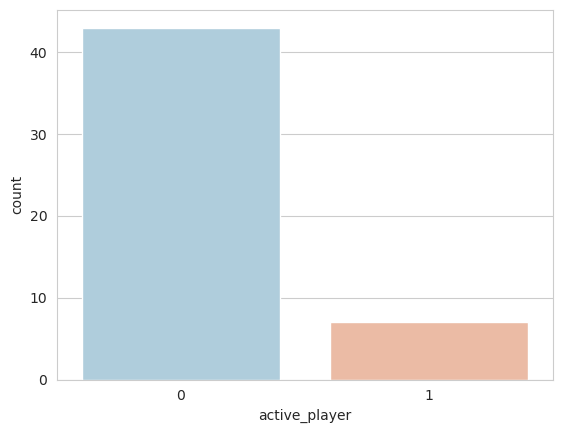

In [62]:
# Cek relative size dari survived dan not survived
sns.set_style('whitegrid')
sns.countplot(x='active_player',data=train,palette='RdBu_r')

<Axes: xlabel='active_player', ylabel='count'>

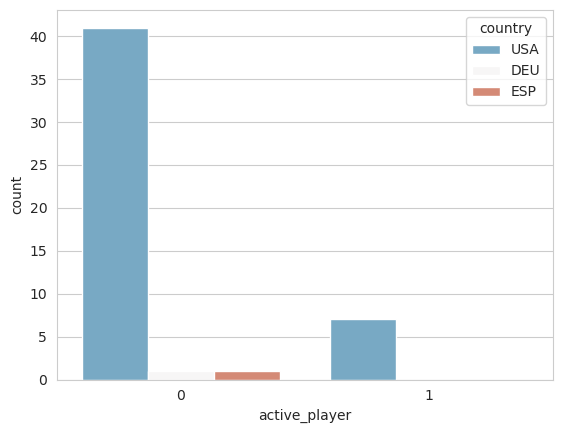

In [63]:
# Survivablity vs sex
sns.set_style('whitegrid')
sns.countplot(x='active_player',hue='country',data=train,palette='RdBu_r')

<Axes: xlabel='active_player', ylabel='count'>

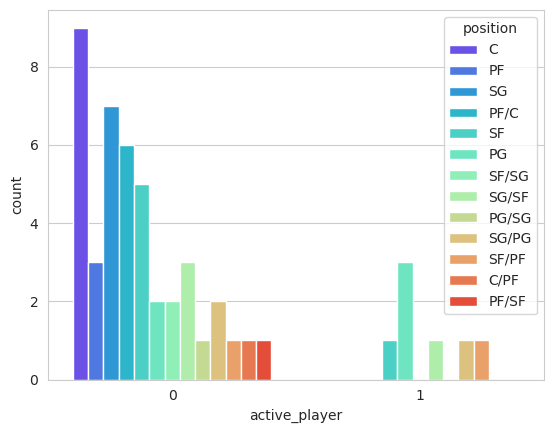

In [64]:
# Survivablity vs passenger class
sns.set_style('whitegrid')
sns.countplot(x='active_player',hue='position',data=train,palette='rainbow')

Text(0.5, 1.0, 'Persentase player yang masih aktif berdasarkan posisi')

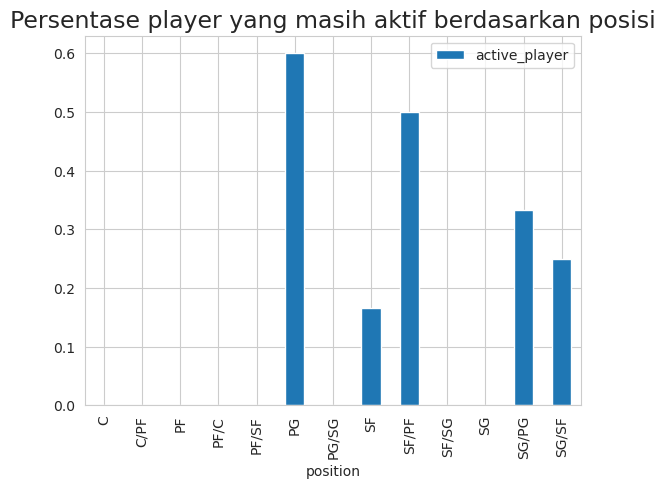

In [65]:
f_class_survived=train.groupby('position')['active_player'].mean()
f_class_survived = pd.DataFrame(f_class_survived)
f_class_survived
f_class_survived.plot.bar(y='active_player')
plt.title("Persentase player yang masih aktif berdasarkan posisi",fontsize=17)

<Axes: xlabel='active_player', ylabel='count'>

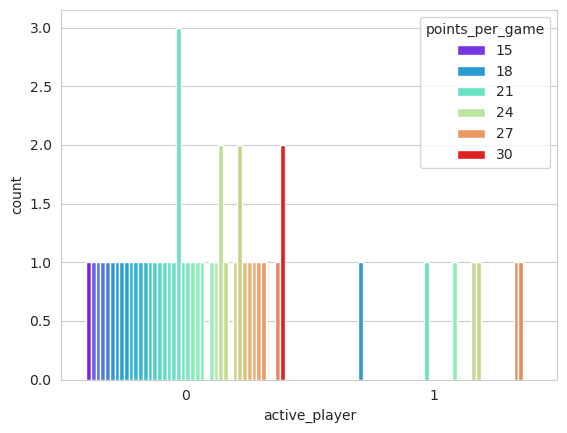

In [66]:
# Survived vs Sibling and Spouses
sns.set_style('whitegrid')
sns.countplot(x='active_player',hue='points_per_game',data=train,palette='rainbow')

<Axes: title={'center': 'Histogram Total Points'}, xlabel='Total Points', ylabel='Count'>

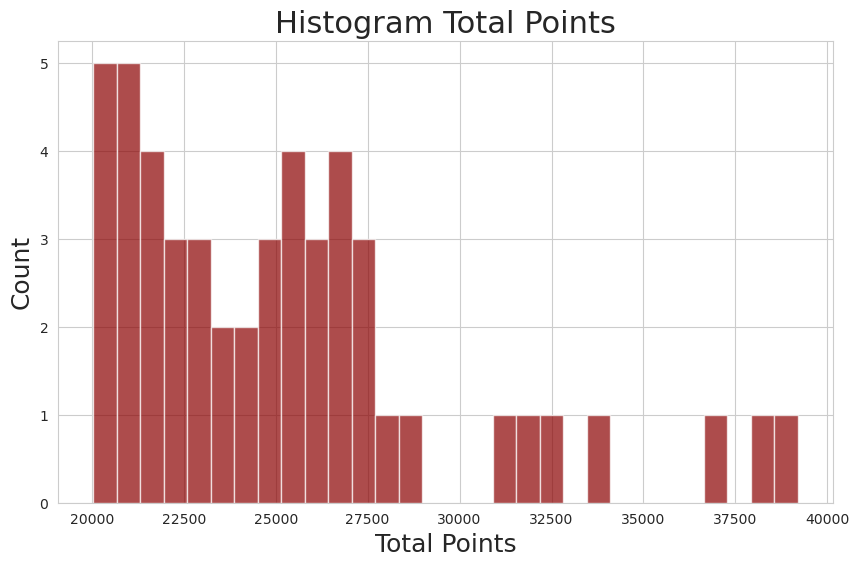

In [67]:
# Cek distribusi dari umur
plt.xlabel("Total Points",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram Total Points",fontsize=22)
train['total_points'].hist(bins=30,color='darkred',alpha=0.7,figsize=(10,6))

/tmp/ipykernel_59009/255657018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='position',y='total_points',data=train,palette='winter')


<Axes: xlabel='country', ylabel='total_points'>

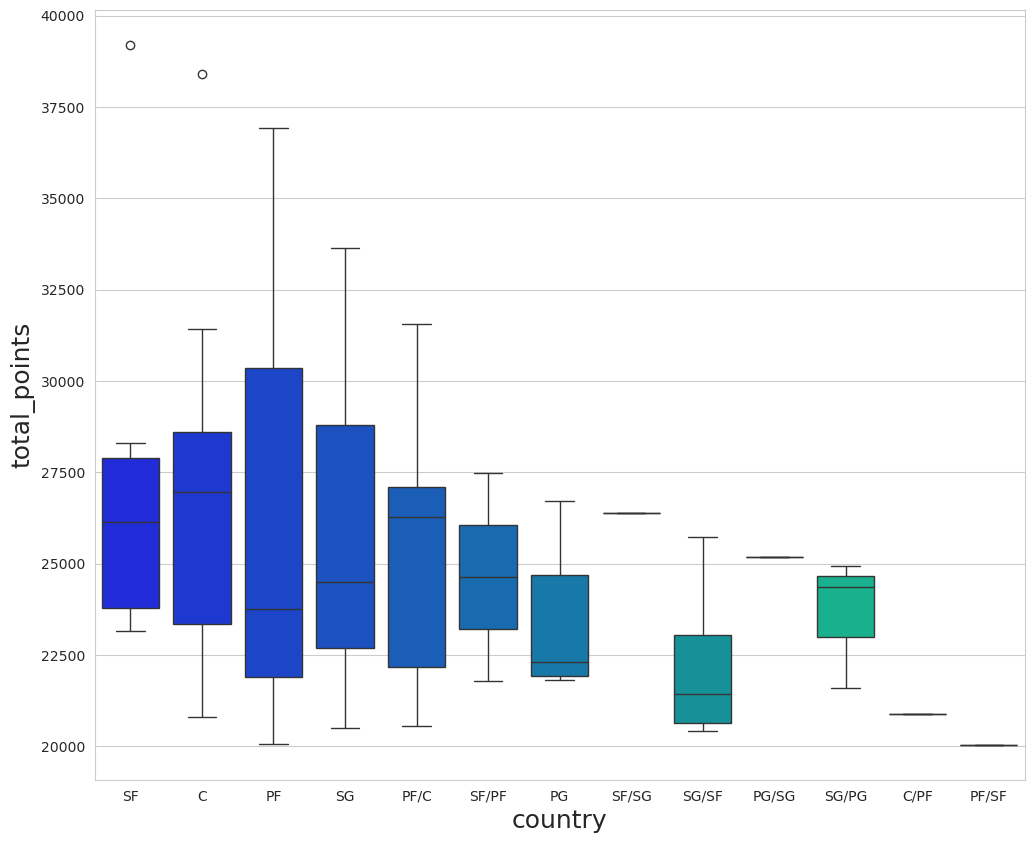

In [68]:
# Distribusi umur di setiap kelas
plt.figure(figsize=(12, 10))
plt.xlabel("country",fontsize=18)
plt.ylabel("total_points",fontsize=18)
sns.boxplot(x='position',y='total_points',data=train,palette='winter')

Text(0.5, 0, 'posisi')

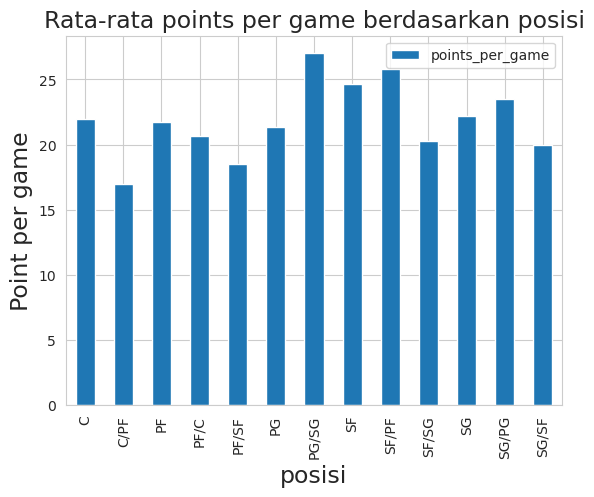

In [69]:
f_class_Age=train.groupby('position')['points_per_game'].mean()
f_class_Age = pd.DataFrame(f_class_Age)
f_class_Age.plot.bar(y='points_per_game')
plt.title("Rata-rata points per game berdasarkan posisi",fontsize=17)
plt.ylabel("Point per game", fontsize=17)
plt.xlabel("posisi", fontsize=17)

### Fitur Engineering

In [70]:
avg_points = train.groupby('position')['total_points'].mean()
a = list(avg_points)

def impute_points(cols):
    points = cols[0]
    position = cols[1]

    if pd.isnull(points):
        if position == 'PG':
            return avg_points['PG']
        elif position == 'SG':
            return avg_points['SG']
        else:
            return avg_points[position]
    else:
        return points

In [71]:
train['total_points'] = train[['total_points','position']].apply(impute_points, axis=1)

/tmp/ipykernel_59009/701612558.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  points = cols[0]
/tmp/ipykernel_59009/701612558.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  position = cols[1]


Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

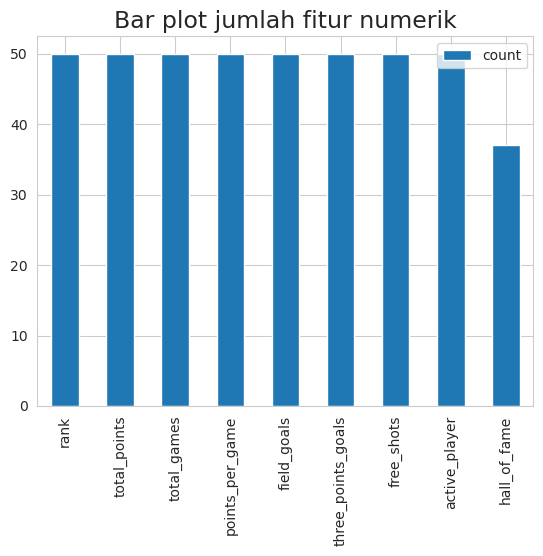

In [72]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [73]:
train.isnull().sum()

rank                   0
player                 0
position               0
teams                  0
total_points           0
total_games            0
points_per_game        0
field_goals            0
three_points_goals     0
free_shots             0
born                   0
active_player          0
hall_of_fame          13
country                0
dtype: int64

In [74]:
train['hall_of_fame'] = train['hall_of_fame'].fillna(0)

In [75]:
# drop cabin karena memiliki banyak null value (>50%)
train.drop('hall_of_fame',axis=1,inplace=True)
train.dropna(inplace=True)
train.head()

,rank,player,position,teams,total_points,total_games,points_per_game,field_goals,three_points_goals,free_shots,born,active_player,country
0,1,LeBron James,SF,"Cleveland Cavaliers (2003–2010, 2014–2018)\nMi...",39201,1443,27.2,14356,2311,8178,1984,1,USA
1,2,Kareem Abdul-Jabbar,C,Milwaukee Bucks (1969–1975)\nLos Angeles Laker...,38387,1560,24.6,15837,1,6712,1947,0,USA
2,3,Karl Malone,PF,Utah Jazz (1985–2003)\nLos Angeles Lakers (200...,36928,1476,25.0,13528,85,9787,1963,0,USA
3,4,Kobe Bryant,SG,Los Angeles Lakers (1996–2016),33643,1346,25.0,11719,1827,8378,1978-2020,0,USA
4,5,Michael Jordan,SG,"Chicago Bulls (1984–1993, 1995–1998)\nWashingt...",32292,1072,30.1,12192,581,7327,1963,0,USA


In [76]:
# Drop semua kolom yang tidak penting
train.drop(['player','teams','country'],axis=1,inplace=True)
train.head()

,rank,position,total_points,total_games,points_per_game,field_goals,three_points_goals,free_shots,born,active_player
0,1,SF,39201,1443,27.2,14356,2311,8178,1984,1
1,2,C,38387,1560,24.6,15837,1,6712,1947,0
2,3,PF,36928,1476,25.0,13528,85,9787,1963,0
3,4,SG,33643,1346,25.0,11719,1827,8378,1978-2020,0
4,5,SG,32292,1072,30.1,12192,581,7327,1963,0


In [77]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['active_player'] = le.fit_transform(train['active_player'])
train['position'] = le.fit_transform(train['position'])
train.head()

,rank,position,total_points,total_games,points_per_game,field_goals,three_points_goals,free_shots,born,active_player
0,1,7,39201,1443,27.2,14356,2311,8178,1984,1
1,2,0,38387,1560,24.6,15837,1,6712,1947,0
2,3,2,36928,1476,25.0,13528,85,9787,1963,0
3,4,10,33643,1346,25.0,11719,1827,8378,1978-2020,0
4,5,10,32292,1072,30.1,12192,581,7327,1963,0


### Training

In [92]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('active_player',axis=1),
                                                    train['active_player'], test_size=0.30,
                                                    random_state=42)

In [93]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (35, 9)
Test shape: (15, 9)


# **KNN**

In [94]:
print(X_train.dtypes)

rank                    int64
position                int64
total_points            int64
total_games             int64
points_per_game       float64
field_goals             int64
three_points_goals      int64
free_shots              int64
born                    int64
dtype: object


In [95]:
train['born'] = train['born'].astype(str).str[:4].astype(int)

In [96]:
train['born'] = train['born'].astype(str).str.extract(r'(\d{4})')[0]
train['born'] = pd.to_numeric(train['born'], errors='coerce')
train['born'] = train['born'].fillna(0).astype(int)

In [97]:
from sklearn.neighbors import KNeighborsClassifier
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [98]:
y_pred = clf1.predict(X_test)

### Evaluation

In [99]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 0.93
Confusion Matrix:
[[14  0]
 [ 1  0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.00      0.00      0.00         1

    accuracy                           0.93        15
   macro avg       0.47      0.50      0.48        15
weighted avg       0.87      0.93      0.90        15



/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [100]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [101]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 0.93
Confusion Matrix:
[[14  0]
 [ 1  0]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.00      0.00      0.00         1

    accuracy                           0.93        15
   macro avg       0.47      0.50      0.48        15
weighted avg       0.87      0.93      0.90        15



/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

### jika ingin mencoba semua parameter

In [102]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits


/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 


=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.828571   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.828571   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.828571   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.828571   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.828571   
11  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.828571   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.828571   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.800000   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.800000   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.771429   
0   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.771429   
1   {'metric': 'euclidea

In [103]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [104]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}


In [105]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  0.93
Presisi:  0.47
Recall:   0.50
F1-Score: 0.48

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.00      0.00      0.00         1

    accuracy                           0.93        15
   macro avg       0.47      0.50      0.48        15
weighted avg       0.87      0.93      0.90        15

Confusion Matrix:
[[14  0]
 [ 1  0]]


/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/hisyam/Downloads/enter/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 